# Figure 5 of Pierard2024TheTile: Toy examples for entity tiles

This jupyter notebook reproduces the three Entity Tiles of Figure 5 in :cite:t:`Pierard2024TheTile'. 

It provides toy examples showing entity tiles showing which of the 4 performances P− , P1 , P2 , and P+ is the best. 
The 3 examples differ in the class priors (either 0.2, 0.5, or 0.8 for the positive class). 
In all examples, P− (green) is the performance of classifiers predicting always the negative class, P1 (purple) is such that TNR(P1)=0.7 and TPR(P1)=0.7, P2 (yellow) is such that TNR(P2)=0.5 and TPR(P2)=0.8, and P+ (grey) is the performance of classifiers predicting always the positive class.

In [1]:
tnr_neg, tpr_neg = 1.0, 0.0
tnr_one, tpr_one = 0.7, 0.7
tnr_two, tpr_two = 0.5, 0.8
tnr_pos, tpr_pos = 0.0, 1.0

In [2]:
from sorbetto.core import Entity
from sorbetto.performance import TwoClassClassificationPerformance
from sorbetto.parameterization import ParameterizationDefault
from sorbetto.tile import EntityTile
from sorbetto.flavor import EntityFlavor
from sorbetto.annotation import AnnotationGridShiftClassPriors, AnnotationGeometric
from sorbetto.ranking import RankingScore

import math
import matplotlib.pyplot as plt

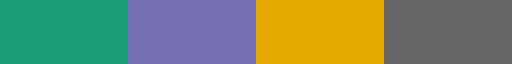

In [3]:
# Print the colormap used for the entity tiles below

cmap = plt.get_cmap("Dark2", 4)

# print(cmap(0))
# print(cmap(1))
# print(cmap(2))
# print(cmap(3))

cmap

In [4]:
def produce_tile ( prior_pos ) :

    def make_perf ( tnr, tpr, name ) :
        ptn = (1.0 - prior_pos) * tnr 
        pfp = (1.0 - prior_pos) * (1.0 - tnr)
        pfn = prior_pos * (1.0 - tpr)
        ptp = prior_pos * tpr
        return TwoClassClassificationPerformance(ptn, pfp, pfn, ptp, name=name)

    # Create the four performances
    P_neg = make_perf ( tnr_neg, tpr_neg, "P-" )
    P_one = make_perf ( tnr_one, tpr_one, "P1" )
    P_two = make_perf ( tnr_two, tpr_two, "P2" )
    P_pos = make_perf ( tnr_pos, tpr_pos, "P+" )
    
    print ( P_neg )
    print ( P_one )
    print ( P_two )
    print ( P_pos )

    # Create the four entities
    entity_neg = Entity(P_neg, name="P-", color=cmap(0))
    entity_one = Entity(P_one, name="P1", color=cmap(1))
    entity_two = Entity(P_two, name="P2", color=cmap(2))
    entity_pos = Entity(P_pos, name="P+", color=cmap(3))
    
    # Create the entity flavor and entity tile for prior pos=0.2 with our four entities
    flavor = EntityFlavor(
        rank=1,
        entity_list=list([entity_neg, entity_one, entity_two, entity_pos])
    )
    tile = EntityTile(
        name="Entity Tile for prior pos={:g}".format ( prior_pos ),
        parameterization=ParameterizationDefault(),
        flavor=flavor,
        resolution=1001
    )
    
    annotation = AnnotationGridShiftClassPriors ( prior_pos_old = 0.5, prior_pos_new = prior_pos, linestyle='-' )
    tile.appendAnnotation ( annotation )
    
    frontier = RankingScore.equivalent( P_pos, P_two )
    annotation = AnnotationGeometric ( frontier, color='k', linewidth=1.5 )
    tile.appendAnnotation ( annotation )
    
    frontier = RankingScore.equivalent( P_two, P_one )
    annotation = AnnotationGeometric ( frontier, color='k', linewidth=1.5 )
    tile.appendAnnotation ( annotation )
    
    frontier = RankingScore.equivalent( P_one, P_neg )
    annotation = AnnotationGeometric ( frontier, color='k', linewidth=1.5 )
    tile.appendAnnotation ( annotation )
    
    # Draw the entity tile
    tile.draw()
    plt.show()

    return tile

## Example 1 for prior pos=0.2

|       | P-   | P1   | P2   | P+   |
| :--:  | :--: | :--: | :--: | :--: |
| *PTN* | 0.80 | 0.56 | 0.40 | 0.00 |
| *PFP* | 0.00 | 0.24 | 0.40 | 0.80 |
| *PFN* | 0.20 | 0.06 | 0.04 | 0.00 |
| *PTP* | 0.00 | 0.14 | 0.16 | 0.20 |

TwoClassClassificationPerformance(name=P-, ptn=0.8, pfp=0.0, pfn=0.2, ptp=0.0)
TwoClassClassificationPerformance(name=P1, ptn=0.5599999999999999, pfp=0.24000000000000005, pfn=0.06000000000000001, ptp=0.13999999999999999)
TwoClassClassificationPerformance(name=P2, ptn=0.4, pfp=0.4, pfn=0.039999999999999994, ptp=0.16000000000000003)
TwoClassClassificationPerformance(name=P+, ptn=0.0, pfp=0.8, pfn=0.0, ptp=0.2)


/Users/pierard/Documents/GitHub/sorbetto/examples/sorbetto/geometry/line_segment.py:65: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([p1.x, p2.x], [p1.y, p2.y], "-", **options_for_plot)


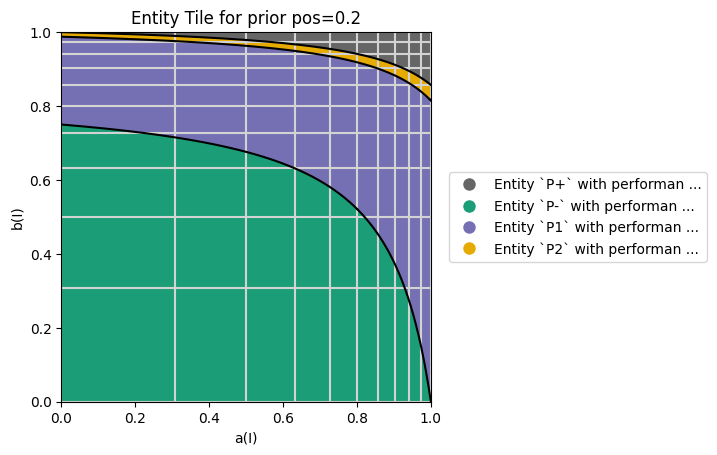

In [5]:
prior_pos = 0.2
example1_entity_tile = produce_tile ( prior_pos )

## Example 2 for prior pos=0.5

|       | P-   | P1   | P2   | P+   |
| :--:  | :--: | :--: | :--: | :--: |
| *PTN* | 0.50 | 0.35 | 0.25 | 0.00 |
| *PFP* | 0.00 | 0.15 | 0.25 | 0.50 |
| *PFN* | 0.50 | 0.15 | 0.10 | 0.00 |
| *PTP* | 0.00 | 0.35 | 0.40 | 0.50 |

TwoClassClassificationPerformance(name=P-, ptn=0.5, pfp=0.0, pfn=0.5, ptp=0.0)
TwoClassClassificationPerformance(name=P1, ptn=0.35, pfp=0.15000000000000002, pfn=0.15000000000000002, ptp=0.35)
TwoClassClassificationPerformance(name=P2, ptn=0.25, pfp=0.25, pfn=0.09999999999999998, ptp=0.4)
TwoClassClassificationPerformance(name=P+, ptn=0.0, pfp=0.5, pfn=0.0, ptp=0.5)


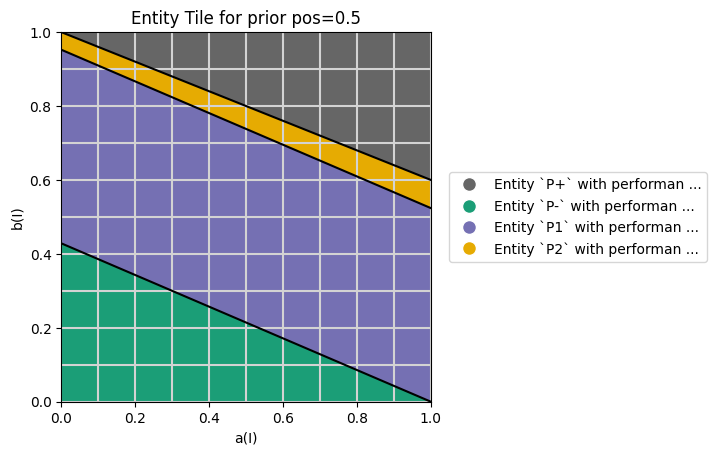

In [6]:
prior_pos = 0.5
example2_entity_tile = produce_tile ( prior_pos )

## Example 3 for prior pos=0.8

|       | P-   | P1   | P2   | P+   |
| :--:  | :--: | :--: | :--: | :--: |
| *PTN* | 0.20 | 0.14 | 0.10 | 0.00 |
| *PFP* | 0.00 | 0.06 | 0.10 | 0.20 |
| *PFN* | 0.80 | 0.24 | 0.16 | 0.00 |
| *PTP* | 0.00 | 0.56 | 0.64 | 0.80 |

TwoClassClassificationPerformance(name=P-, ptn=0.19999999999999996, pfp=0.0, pfn=0.8, ptp=0.0)
TwoClassClassificationPerformance(name=P1, ptn=0.13999999999999996, pfp=0.06, pfn=0.24000000000000005, ptp=0.5599999999999999)
TwoClassClassificationPerformance(name=P2, ptn=0.09999999999999998, pfp=0.09999999999999998, pfn=0.15999999999999998, ptp=0.6400000000000001)
TwoClassClassificationPerformance(name=P+, ptn=0.0, pfp=0.19999999999999996, pfn=0.0, ptp=0.8)


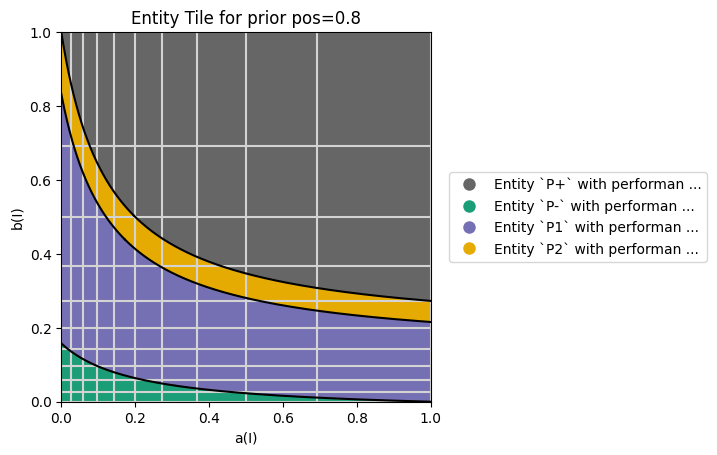

In [7]:
prior_pos = 0.8
example3_entity_tile = produce_tile ( prior_pos )

## The 3 Entity Tiles showing who is ranked number one among 4 performances P− , P1 , P2 , and P+ for 3 different class priors

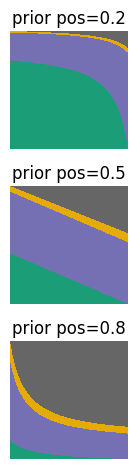

In [8]:
import matplotlib.pyplot as plt

# Initialise the subplot figure and axis
figure, axis = plt.subplots(3, 1)

example1_entity_tile.name = "prior pos=0.2"
example1_entity_tile.disable_legend = True
example1_entity_tile.clearAnnotations()
example1_entity_tile.draw(fig=figure, ax=axis[0])
axis[0].axis("off")

example2_entity_tile.name = "prior pos=0.5"
example2_entity_tile.disable_legend = True
example2_entity_tile.clearAnnotations()
example2_entity_tile.draw(fig=figure, ax=axis[1])
axis[1].axis("off")

example3_entity_tile.name = "prior pos=0.8"
example3_entity_tile.disable_legend = True
example3_entity_tile.clearAnnotations()
example3_entity_tile.draw(fig=figure, ax=axis[2])
axis[2].axis("off")

figure.tight_layout()
plt.show()